# КЛЮЧ · решения для преподавателя

Вывод получен локальным прогоном (RTX 4060, папка весов `weights`); в Colab числа будут немного другими.


# Сохранение весов и дообучение модели
**Курс Machine Learning · преподаватель Ибрахим**

План ноутбука:

1. датасет цветов: скачиваем и превращаем в массивы `x_all`, `y_all`;
2. делим на **обучающую** и **проверочную** выборки;
3. модель и функция обучения;
4. сохраняем веса в файл и загружаем их в новую модель;
5. сохраняем веса **после каждой эпохи** с датой и ошибкой в имени файла;
6. **дообучаем** лучшую модель на меньшем `learning rate`;
7. разбор частых ошибок;
8. **домашнее задание LXP** — повторить всё самостоятельно, с подсказками.

Ячейки **ПОКАЗЫВАЮ** — запустить и посмотреть. Ячейки **ПИШЕМ ВМЕСТЕ** — код, который разбираем на паре строка за строкой.
Домашнее задание в конце — те же шаги самостоятельно, с подсказками.

В Colab включите GPU: «Среда выполнения → Сменить среду выполнения → GPU».

In [1]:
import os                           # пути к файлам и папкам, создание папки для весов
import glob                         # список файлов по шаблону: все картинки класса, все файлы весов
import zipfile                      # распаковка архива с датасетом
import datetime                     # текущие дата и время — для имени файла весов
import numpy as np                  # картинка PIL -> массив чисел
import torch                        # тензоры, сохранение и загрузка весов (torch.save / torch.load)
from torch import nn                # слои нейросети: Conv2d, Linear, ...
import torch.nn.functional as F     # функции без весов: cross_entropy, softmax
from PIL import Image               # открыть картинку и изменить её размер
import matplotlib.pyplot as plt     # картинки и графики обучения

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('устройство:', device)

устройство: cuda


### Папка для весов на Google Диске
Всё, что лежит в `/content`, **стирается**, когда Colab отключает сеанс. Веса храним на Диске.
При запуске Colab попросит разрешить доступ к Диску — это нужно один раз за сеанс.

In [2]:
try:
    from google.colab import drive     # подключение Google Диска к Colab
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/IThub/ML/weights'
except ImportError:          # запуск не в Colab — сохраняем рядом с ноутбуком
    SAVE_DIR = 'weights'

os.makedirs(SAVE_DIR, exist_ok=True)
print('веса будут лежать в:', SAVE_DIR)

веса будут лежать в: weights


---
# Блок 1. Датасет занятия

Архив `flowers.zip` (236 МБ): 5 папок — по одной на вид цветка. Фото разного размера, поэтому
при загрузке **приводим всё к одному размеру** `IMG × IMG`.

`gdown` качает файлы с Google Диска по их id, в Colab он уже установлен
(на своём компьютере: `pip install gdown`).

In [3]:
# ПОКАЗЫВАЮ: скачиваем и распаковываем (один раз за сеанс)
import gdown   # скачивает файл с Google Диска по его id

if not os.path.exists('flowers.zip'):
    gdown.download(id='1mac4-MnUw1ob05wfRlQJyQgVaZlnHkg0', output='flowers.zip')
if not os.path.exists('flowers'):
    zipfile.ZipFile('flowers.zip').extractall('.')

print(sorted(os.listdir('flowers')))

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [4]:
# ПОКАЗЫВАЮ: все картинки -> один массив чисел
IMG = 96

def load_folder(root, size):
    classes = sorted(d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d)))
    xs, ys = [], []
    for label, name in enumerate(classes):
        for path in sorted(glob.glob(os.path.join(root, name, '*'))):
            img = Image.open(path)
            img.draft('RGB', (size, size))          # ускоряет чтение больших JPEG
            img = img.convert('RGB').resize((size, size))
            xs.append(np.array(img))
            ys.append(label)
    x = torch.tensor(np.stack(xs)).permute(0, 3, 1, 2)   # [N, H, W, 3] -> [N, 3, H, W]
    y = torch.tensor(ys)
    return x, y, classes


x_all, y_all, classes = load_folder('flowers', IMG)
print('x_all:', tuple(x_all.shape), x_all.dtype)
print('y_all:', tuple(y_all.shape))
print('классы:', classes)

x_all: (4317, 3, 96, 96) torch.uint8
y_all: (4317,)
классы: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


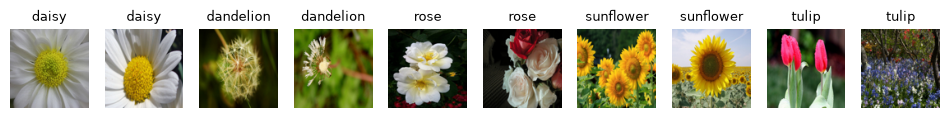

In [5]:
# ПОКАЗЫВАЮ: по две картинки каждого класса
plt.figure(figsize=(12, 3))
for k in range(len(classes)):
    first = (y_all == k).nonzero()[0].item()
    for j in range(2):
        plt.subplot(1, 2 * len(classes), 2 * k + j + 1)
        plt.imshow(x_all[first + j].permute(1, 2, 0))
        plt.title(classes[k], fontsize=9)
        plt.axis('off')
plt.show()

### Задание 1.1
Посчитайте, сколько картинок в каждом классе, и напечатайте построчно `название: количество`.

*Должно получиться:* `daisy: 764`, `dandelion: 1052`, `rose: 784`, `sunflower: 733`, `tulip: 984`.

<details><summary>Подсказка</summary>

`torch.bincount(y_all)` считает, сколько раз встречается каждая метка 0, 1, 2…
Дальше — цикл по `range(len(classes))`.
</details>

In [6]:
# РЕШЕНИЕ 1.1

counts = torch.bincount(y_all)
for k in range(len(classes)):
    print(f'{classes[k]}: {counts[k].item()}')

daisy: 764
dandelion: 1052
rose: 784
sunflower: 733
tulip: 984


---
# Блок 2. Обучающая и проверочная выборки

* **обучающая** (`x_train`, `y_train`) — на ней сеть учится;
* **проверочная** (`x_val`, `y_val`) — сеть её **никогда не видит при обучении**. По ней решаем,
  какая эпоха лучшая и помогло ли дообучение.

Картинки в `x_all` лежат **по порядку классов**: сначала все ромашки, потом все одуванчики…
Если просто отрезать последние 15 %, в проверку попадут одни тюльпаны. Поэтому **сначала перемешиваем
номера**, потом режем.

> В методичке LXP массивы называются `x_train`, `y_train` и их делят на `x_train/y_train` и `x_val/y_val`.
> У нас исходные массивы названы `x_all`, `y_all`, чтобы повторный запуск ячейки не резал уже разрезанное.

In [7]:
# ПОКАЗЫВАЮ: перемешанные номера — на маленьком примере
print(torch.randperm(10))

tensor([4, 1, 7, 5, 3, 9, 0, 8, 6, 2])


### Задание 2.1
Разделите `x_all`, `y_all` на обучающую и проверочную выборки: **15 %** — в проверку.
Напечатайте формы всех четырёх массивов.

*Должно получиться:* `x_train (3670, 3, 96, 96)`, `x_val (647, 3, 96, 96)`, у `y_*` — те же первые числа.

<details><summary>Подсказка</summary>

1. `idx = torch.randperm(len(x_all))` — перемешанные номера всех картинок.
2. `n_val = int(len(x_all) * 0.15)` — сколько уходит в проверку.
3. Первые `n_val` номеров — проверка, остальные — обучение: срезы `idx[:n_val]` и `idx[n_val:]`.
4. Массив по списку номеров: `x_all[номера]`.
</details>

In [8]:
# РЕШЕНИЕ 2.1

idx = torch.randperm(len(x_all))
n_val = int(len(x_all) * 0.15)
val_idx, train_idx = idx[:n_val], idx[n_val:]

x_train, y_train = x_all[train_idx], y_all[train_idx]
x_val, y_val = x_all[val_idx], y_all[val_idx]

print('x_train', tuple(x_train.shape), '| y_train', tuple(y_train.shape))
print('x_val  ', tuple(x_val.shape), '| y_val  ', tuple(y_val.shape))

x_train (3670, 3, 96, 96) | y_train (3670,)
x_val   (647, 3, 96, 96) | y_val   (647,)


### Задание 2.2
Проверьте, что в проверочную выборку попали **все** классы: напечатайте, сколько картинок каждого класса
в `y_val` и какую долю от класса это составляет.

*Должно получиться:* у всех классов доля около 0.15 (±0.03).

In [9]:
# РЕШЕНИЕ 2.2

val_counts = torch.bincount(y_val, minlength=len(classes))
all_counts = torch.bincount(y_all)
for k in range(len(classes)):
    print(f'{classes[k]:10s} {val_counts[k].item():4d}  доля {val_counts[k].item() / all_counts[k].item():.2f}')

daisy       104  доля 0.14
dandelion   153  доля 0.15
rose        130  доля 0.17
sunflower   122  доля 0.17
tulip       138  доля 0.14


### Пачки: `TensorDataset` и `DataLoader`
* `TensorDataset(x, y)` — склеивает картинки и метки в пары: `ds[i]` → `(картинка, метка)`;
* `DataLoader(ds, batch_size=64, shuffle=True)` — раздаёт эти пары **пачками** и перемешивает их каждую эпоху;
  для проверки перемешивать незачем.

Картинки уже в памяти, поэтому `DataLoader` их не перечитывает с диска — обучение быстрое.

In [10]:
# ПОКАЗЫВАЮ: пачки для обучения и проверки
from torch.utils.data import TensorDataset, DataLoader   # раздают данные пачками

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=256)

xb, yb = next(iter(train_loader))
print('пачек за эпоху:', len(train_loader), '| одна пачка:', tuple(xb.shape), tuple(yb.shape))

пачек за эпоху: 58 | одна пачка: (64, 3, 96, 96) (64,)


---
# Блок 3. Модель и функция обучения

Сеть — три свёрточных блока и классификатор. Функцию `fit` даю готовой, в ней две новые вещи:

* `history` — общий **журнал обучения**: каждая эпоха дописывается в конец, номера эпох продолжаются
  от цикла к циклу (как `initial_epoch` в Keras);
* `callback` — **функция, которую `fit` вызывает после каждой эпохи** (как `callbacks` в Keras).
  Через неё в блоке 5 будем сохранять веса.

Картинки храним как `uint8` (0…255), а в сеть подаём `float` 0…1 — делим на 255 прямо перед подачей.

In [11]:
# ПОКАЗЫВАЮ: модель занятия
def make_model():
    return nn.Sequential(
        nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 96 -> 48
        nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 48 -> 24
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 24 -> 12
        nn.Flatten(),
        nn.Dropout(0.3),
        nn.Linear(64 * 12 * 12, len(classes)),
    ).to(device)


print('выход:', tuple(make_model()(torch.zeros(2, 3, IMG, IMG, device=device)).shape))
print('параметров:', sum(p.numel() for p in make_model().parameters()))

выход: (2, 5)
параметров: 69669


In [12]:
# ПОКАЗЫВАЮ: проверка и обучение
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device).float() / 255
            yb = yb.to(device)
            out = model(xb)
            loss_sum += F.cross_entropy(out, yb, reduction='sum').item()
            correct += (out.argmax(dim=1) == yb).sum().item()
            count += len(yb)
    return loss_sum / count, correct / count


def fit(model, epochs, lr, history, callback=None):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    cycle = history[-1]['cycle'] + 1 if history else 1
    for _ in range(epochs):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for xb, yb in train_loader:                                   # пачки по 64, перемешаны
            xb = xb.to(device).float() / 255
            yb = yb.to(device)
            flip = torch.rand(len(xb), device=device) < 0.5          # половину пачки отражаем
            xb = torch.where(flip[:, None, None, None], xb.flip(3), xb)
            out = model(xb)
            loss = F.cross_entropy(out, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            loss_sum += loss.item() * len(xb)
            correct += (out.argmax(dim=1) == yb).sum().item()
            count += len(xb)
        val_loss, val_acc = evaluate(model, val_loader)
        epoch = len(history) + 1
        history.append({'epoch': epoch, 'cycle': cycle, 'lr': lr,
                        'train_loss': loss_sum / count, 'train_acc': correct / count,
                        'val_loss': val_loss, 'val_acc': val_acc})
        print(f'эпоха {epoch:2d} | train loss {loss_sum / count:.4f} acc {correct / count:.3f}'
              f' | val loss {val_loss:.4f} acc {val_acc:.3f}')
        if callback:
            callback(model, epoch, val_loss)


def plot_history(history):
    ep = [h['epoch'] for h in history]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, key, title in [(axes[0], 'loss', 'ошибка (loss)'), (axes[1], 'acc', 'точность')]:
        ax.plot(ep, [h['train_' + key] for h in history], 'o-', label='обучающая')
        ax.plot(ep, [h['val_' + key] for h in history], 'o-', label='проверочная')
        for a, b in zip(history, history[1:]):
            if a['cycle'] != b['cycle']:
                ax.axvline(a['epoch'] + 0.5, color='gray', ls='--')
        ax.set_title(title)
        ax.set_xlabel('эпоха')
        ax.legend()
    plt.show()

### Задание 3.1
Создайте модель `model = make_model()`, пустой журнал `history = []` и обучите **3 эпохи** с `lr=1e-3`.

*Должно получиться:* три строки, точность на проверке растёт и к третьей эпохе около 0.55–0.65.

In [13]:
# РЕШЕНИЕ 3.1

model = make_model()
history = []
fit(model, 3, 1e-3, history)

эпоха  1 | train loss 1.3287 acc 0.430 | val loss 1.1469 acc 0.535


эпоха  2 | train loss 1.0895 acc 0.565 | val loss 1.0598 acc 0.590


эпоха  3 | train loss 1.0171 acc 0.596 | val loss 1.0538 acc 0.594


---
# Блок 4. Сохранить и загрузить веса

**Веса** — это всё, чему сеть научилась: числа во всех ядрах и нейронах. В PyTorch они лежат в словаре
`model.state_dict()`: **имя слоя → тензор**.

| что делаем | PyTorch | Keras (методичка LXP) |
|---|---|---|
| сохранить | `torch.save(model.state_dict(), path)` | `model.save_weights(path)` |
| загрузить | `model.load_state_dict(torch.load(path))` | `model.load_weights(path)` |
| расширение | `.pt` | `.hdf5` / `.weights.h5` |

Сохраняются **только числа**, не архитектура. Загружать веса можно только в **такую же** модель.

In [14]:
# ПОКАЗЫВАЮ: что внутри state_dict
for name, w in model.state_dict().items():
    print(f'{name:10s} {tuple(w.shape)}')

0.weight   (16, 3, 3, 3)
0.bias     (16,)
3.weight   (32, 16, 3, 3)
3.bias     (32,)
6.weight   (64, 32, 3, 3)
6.bias     (64,)
11.weight  (5, 9216)
11.bias    (5,)


### Задание 4.1
Сохраните веса обученной модели в файл `flowers.pt` в папке `SAVE_DIR` и напечатайте размер файла в КБ.

*Должно получиться:* файл около 280 КБ.

<details><summary>Подсказка</summary>

Путь к файлу: `SAVE_DIR + '/flowers.pt'`. Размер в байтах — `os.path.getsize(путь)`, делим на 1024.
</details>

In [15]:
# РЕШЕНИЕ 4.1

path = SAVE_DIR + '/flowers.pt'
torch.save(model.state_dict(), path)
print('сохранено:', path, '|', round(os.path.getsize(path) / 1024), 'КБ')

сохранено: weights/flowers.pt | 275 КБ


### Задание 4.2
Создайте **новую** модель `model2 = make_model()` и посчитайте её точность на проверке функцией `evaluate`.
Затем загрузите в неё веса из `flowers.pt` и посчитайте точность ещё раз.

*Должно получиться:* до загрузки — около 0.2 (угадывание из 5 классов), после — **ровно** как у `model`.

<details><summary>Подсказка</summary>

`evaluate(модель, val_loader)` возвращает пару `(loss, точность)`.
Загрузка в две операции: `torch.load(путь)` читает словарь из файла, `model2.load_state_dict(словарь)` раскладывает числа по слоям.
</details>

In [16]:
# РЕШЕНИЕ 4.2

model2 = make_model()
print('новая модель    : loss %.4f, точность %.3f' % evaluate(model2, val_loader))
model2.load_state_dict(torch.load(SAVE_DIR + '/flowers.pt'))
print('после загрузки  : loss %.4f, точность %.3f' % evaluate(model2, val_loader))
print('исходная модель : loss %.4f, точность %.3f' % evaluate(model, val_loader))

новая модель    : loss 1.6081, точность 0.204


после загрузки  : loss 1.0538, точность 0.594


исходная модель : loss 1.0538, точность 0.594


---
# Блок 5. Веса после каждой эпохи

Сохранять один раз в конце — рискованно: сеанс может оборваться, а последняя эпоха часто **не лучшая**.
Поэтому сохраняем после **каждой** эпохи, а в имя файла пишем дату и ошибку на проверке:

```
flowers-2026-10-06_14-30_007-0.812345.pt
        дата и время  эпоха  val_loss
```

Шаблон имени — как в методичке: `{epoch:03d}` — номер эпохи тремя цифрами, `{val_loss:.6f}` — ошибка
с шестью знаками. Метод строк `.format(...)` подставляет числа в фигурные скобки.

In [17]:
# ПОКАЗЫВАЮ: шаблон имени и подстановка
weights = SAVE_DIR + '/flowers-@@dt@@_{epoch:03d}-{val_loss:.6f}.pt'
dt = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M')
weights = weights.replace('@@dt@@', dt)

print(weights)
print(weights.format(epoch=7, val_loss=0.8123449))

weights/flowers-2026-10-04_22-12_{epoch:03d}-{val_loss:.6f}.pt
weights/flowers-2026-10-04_22-12_007-0.812345.pt


### Задание 5.1
Напишите функцию `checkpoint(model, epoch, val_loss)`, которая сохраняет веса модели в файл по шаблону `weights`.
Проверьте её: вызовите для `model` с эпохой `0` и её настоящей ошибкой на проверке, затем напечатайте
список файлов в `SAVE_DIR`.

*Должно получиться:* в папке появился файл вида `flowers-…_000-0.9….pt`.

<details><summary>Подсказка</summary>

Внутри две строки: путь `weights.format(epoch=epoch, val_loss=val_loss)` и `torch.save(...)` как в задании 4.1.
Ошибку на проверке даёт `evaluate(model, val_loader)[0]`. Список файлов — `os.listdir(SAVE_DIR)`.
</details>

In [18]:
# РЕШЕНИЕ 5.1

def checkpoint(model, epoch, val_loss):
    path = weights.format(epoch=epoch, val_loss=val_loss)
    torch.save(model.state_dict(), path)


checkpoint(model, 0, evaluate(model, val_loader)[0])
print(sorted(os.listdir(SAVE_DIR)))

['flowers-2026-10-04_22-12_000-1.053820.pt', 'flowers.pt']


### Задание 5.2 · первый цикл обучения
Создайте **новую** модель и новый журнал `history = []` и обучите **20 эпох** с `lr=1e-3`,
передав `callback=checkpoint`.

*Должно получиться:* 20 строк обучения и 20 новых файлов весов. Точность на проверке к концу — около 0.7.

In [19]:
# РЕШЕНИЕ 5.2

model = make_model()
history = []
fit(model, 20, 1e-3, history, callback=checkpoint)
print('файлов этого запуска:', len(glob.glob(SAVE_DIR + f'/flowers-{dt}_*.pt')))

эпоха  1 | train loss 1.4500 acc 0.360 | val loss 1.2676 acc 0.504


эпоха  2 | train loss 1.1308 acc 0.538 | val loss 1.0955 acc 0.549


эпоха  3 | train loss 1.0289 acc 0.589 | val loss 1.0181 acc 0.595


эпоха  4 | train loss 0.9596 acc 0.622 | val loss 0.9717 acc 0.631


эпоха  5 | train loss 0.9440 acc 0.626 | val loss 0.9565 acc 0.621


...

эпоха 16 | train loss 0.6088 acc 0.769 | val loss 0.7386 acc 0.723


эпоха 17 | train loss 0.5893 acc 0.778 | val loss 0.7137 acc 0.726


эпоха 18 | train loss 0.5511 acc 0.793 | val loss 0.8575 acc 0.689


эпоха 19 | train loss 0.5435 acc 0.798 | val loss 0.7679 acc 0.728


эпоха 20 | train loss 0.5274 acc 0.796 | val loss 0.7720 acc 0.708
файлов этого запуска: 21


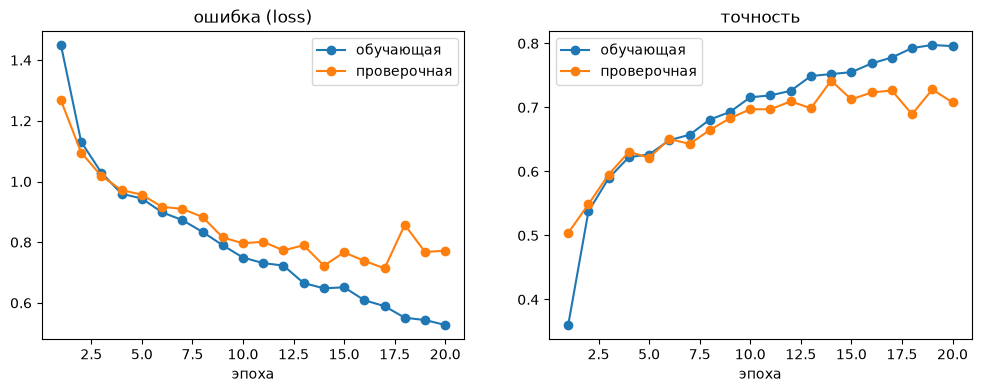

In [20]:
# ПОКАЗЫВАЮ: графики первого цикла
plot_history(history)

### Задание 5.3 · найти лучшие веса
Представьте, что сеанс оборвался и журнал `history` пропал — остались только файлы.
Найдите среди файлов **этого запуска** тот, у которого **наименьший** `val_loss` в имени,
загрузите его в модель и напечатайте его имя и точность на проверке.

*Должно получиться:* имя файла с самым маленьким числом в конце; точность совпадает с той эпохой в журнале.

<details><summary>Подсказка</summary>

* файлы запуска: `glob.glob(SAVE_DIR + f'/flowers-{dt}_*.pt')`;
* ошибка из имени `'.../flowers-…_007-0.812345.pt'`: отрезать `.pt` (`p[:-3]`) и взять то, что после **последнего** дефиса: `.rsplit('-', 1)[1]`, затем `float(...)`;
* самый маленький по правилу: `min(files, key=функция_которая_достаёт_ошибку)`.
</details>

In [21]:
# РЕШЕНИЕ 5.3

def loss_from_name(p):
    return float(p[:-3].rsplit('-', 1)[1])


files = glob.glob(SAVE_DIR + f'/flowers-{dt}_*.pt')
files = [p for p in files if '_000-' not in p]          # пробный файл из задания 5.1 не считаем
best_path = min(files, key=loss_from_name)

model.load_state_dict(torch.load(best_path))
print('лучший файл:', os.path.basename(best_path))
print('проверка   : loss %.4f, точность %.3f' % evaluate(model, val_loader))

лучший файл: flowers-2026-10-04_22-12_017-0.713699.pt
проверка   : loss 0.7137, точность 0.726


---
# Блок 6. Дообучение

**Дообучение** — продолжаем учить уже обученную сеть, а не начинаем с нуля. Делают это, чтобы:

* выжать ещё точности — с **меньшим** шагом `lr`, сеть аккуратно спускается в найденную ямку ошибки;
* добавить **новые данные** — догрузили фото, учим дальше с сохранённых весов.

Порядок: загрузили **лучшие** веса (уже сделали в 5.3) → `fit` с `lr` в 10 раз меньше → снова сохраняем каждую эпоху.

### Задание 6.1 · второй цикл
Дообучите `model` **6 эпох** с `lr=1e-4`, продолжая **тот же** журнал `history` и с тем же `checkpoint`.
Потом нарисуйте графики `plot_history(history)`.

*Должно получиться:* номера эпох продолжаются с 21; на графике пунктир — граница циклов;
ошибка на проверке во втором цикле ниже, чем была в лучшую эпоху первого.

<details><summary>Подсказка</summary>

Тот же вызов `fit`, что в 5.2, но модель **не создаём заново** — иначе выучилось бы с нуля.
</details>

эпоха 21 | train loss 0.5079 acc 0.814 | val loss 0.6968 acc 0.734


эпоха 22 | train loss 0.4990 acc 0.818 | val loss 0.6940 acc 0.739


эпоха 23 | train loss 0.4868 acc 0.819 | val loss 0.7089 acc 0.740


эпоха 24 | train loss 0.4802 acc 0.825 | val loss 0.6904 acc 0.743


эпоха 25 | train loss 0.4868 acc 0.818 | val loss 0.7002 acc 0.742


эпоха 26 | train loss 0.4855 acc 0.825 | val loss 0.6824 acc 0.756


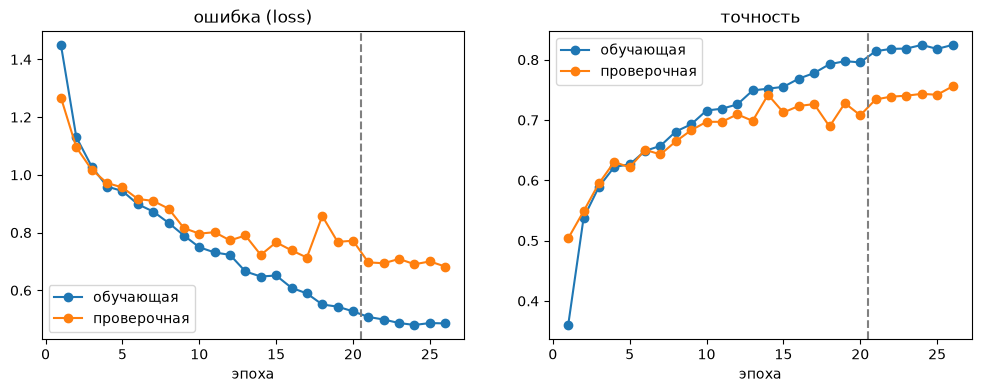

In [22]:
# РЕШЕНИЕ 6.1

fit(model, 6, 1e-4, history, callback=checkpoint)
plot_history(history)

### Задание 6.2 · стало ли лучше
Для каждого цикла напечатайте **лучшую** эпоху: номер, `val_loss` и `val_acc`.

*Должно получиться:* две строки. У второго цикла `val_loss` обычно немного ниже. Прирост точности бывает от нуля до нескольких процентных пунктов — чем лучше обучился первый цикл, тем меньше остаётся дообучению.

<details><summary>Подсказка</summary>

Строки журнала одного цикла: `[h for h in history if h['cycle'] == c]`. Лучшая — `min(..., key=lambda h: h['val_loss'])`.
</details>

In [23]:
# РЕШЕНИЕ 6.2

for c in sorted({h['cycle'] for h in history}):
    rows = [h for h in history if h['cycle'] == c]
    best = min(rows, key=lambda h: h['val_loss'])
    print(f"цикл {c} (lr={best['lr']}): лучшая эпоха {best['epoch']:2d} | "
          f"val_loss {best['val_loss']:.4f} | val_acc {best['val_acc']:.3f}")

цикл 1 (lr=0.001): лучшая эпоха 17 | val_loss 0.7137 | val_acc 0.726
цикл 2 (lr=0.0001): лучшая эпоха 26 | val_loss 0.6824 | val_acc 0.756


---
# Блок 7. Частые ошибки

In [24]:
# ПОКАЗЫВАЮ: веса от одной архитектуры нельзя загрузить в другую
other = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 32 фильтра вместо 16
    nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Dropout(0.3), nn.Linear(64 * 12 * 12, len(classes)),
)
try:
    other.load_state_dict(torch.load(best_path))
except RuntimeError as e:
    print(str(e)[:300])

Error(s) in loading state_dict for Sequential:
	size mismatch for 0.weight: copying a param with shape torch.Size([16, 3, 3, 3]) from checkpoint, the shape in current model is torch.Size([32, 3, 3, 3]).
	size mismatch for 0.bias: copying a param with shape torch.Size([16]) from checkpoint, the shape


In [25]:
# ПОКАЗЫВАЮ: веса, сохранённые на GPU, на компьютере без GPU грузят с map_location
sd = torch.load(best_path, map_location='cpu')
print('устройство тензоров:', next(iter(sd.values())).device)

устройство тензоров: cpu


| ошибка | почему | как чинить |
|---|---|---|
| `Missing key(s)` / `size mismatch` | архитектура модели не та, что при сохранении | создать модель тем же кодом |
| `FileNotFoundError` | Диск не подключён или опечатка в пути | запустить ячейку с `drive.mount`, напечатать путь |
| дообучение «сломало» модель | `lr` такой же большой, как в первом цикле | уменьшить в 10 раз |
| дообучение пошло с нуля | создали `make_model()` заново перед `fit` | грузить веса в модель и учить **её** |
| проверка из одного класса | не перемешали перед разрезанием | `torch.randperm` перед срезами |

---
---
# ДОМАШНЕЕ ЗАДАНИЕ LXP · «Разделить выборку на обучающую и проверочную» · 2 балла

Повторите путь занятия **самостоятельно**, с другими настройками. Каждый шаг уже делали на паре —
в подсказке написано, в каком блоке смотреть.

Перед началом: «Среда выполнения → Перезапустить сеанс», затем запустите ячейки **до блока 1 включительно**
(импорты, Диск, `load_folder`), но поменяйте `IMG = 128`.

### Шаг 1. Разделение
Разделите `x_all`, `y_all` на `x_train/y_train` и `x_val/y_val`, в проверку — **20 %**.
Напечатайте формы и количество картинок каждого класса в проверке.

<details><summary>Подсказка</summary>Блок 2, задания 2.1 и 2.2 — поменяйте только долю. После разделения заново создайте <code>train_loader</code> и <code>val_loader</code>: старые держат прежние картинки 96 × 96.</details>

In [26]:
# РЕШЕНИЕ ДЗ · шаг 1

IMG = 128
x_all, y_all, classes = load_folder('flowers', IMG)

idx = torch.randperm(len(x_all))
n_val = int(len(x_all) * 0.2)
x_train, y_train = x_all[idx[n_val:]], y_all[idx[n_val:]]
x_val, y_val = x_all[idx[:n_val]], y_all[idx[:n_val]]
print('x_train', tuple(x_train.shape), '| x_val', tuple(x_val.shape))
print('в проверке по классам:', torch.bincount(y_val).tolist())

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=256)

x_train (3454, 3, 128, 128) | x_val (863, 3, 128, 128)
в проверке по классам: [135, 238, 149, 148, 193]


### Шаг 2. Модель под размер 128
Модель занятия рассчитана на 96 × 96. Напишите `make_model()` для 128 × 128 и проверьте форму выхода
на `torch.zeros(2, 3, IMG, IMG)`.

<details><summary>Подсказка</summary>После трёх MaxPool2d(2): 128 → 64 → 32 → 16. Значит, вход Linear — <code>64 * 16 * 16</code>.</details>

In [27]:
# РЕШЕНИЕ ДЗ · шаг 2

def make_model():
    return nn.Sequential(
        nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 128 -> 64
        nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 64 -> 32
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 32 -> 16
        nn.Flatten(),
        nn.Dropout(0.3),
        nn.Linear(64 * 16 * 16, len(classes)),
    ).to(device)


print('выход:', tuple(make_model()(torch.zeros(2, 3, IMG, IMG, device=device)).shape))

выход: (2, 5)


### Шаг 3. Первый цикл с сохранением каждой эпохи
Шаблон имени `weights` с датой (блок 5), функция `checkpoint`, обучение **15 эпох** с `lr=1e-3`.

<details><summary>Подсказка</summary>Блок 5: ячейка с шаблоном, задания 5.1 и 5.2. Не забудьте запустить ячейку с <code>fit</code> и <code>evaluate</code> из блока 3.</details>

In [28]:
# РЕШЕНИЕ ДЗ · шаг 3

weights = SAVE_DIR + '/flowers128-@@dt@@_{epoch:03d}-{val_loss:.6f}.pt'
dt = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M')
weights = weights.replace('@@dt@@', dt)


def checkpoint(model, epoch, val_loss):
    torch.save(model.state_dict(), weights.format(epoch=epoch, val_loss=val_loss))


model = make_model()
history = []
fit(model, 15, 1e-3, history, callback=checkpoint)

эпоха  1 | train loss 1.3300 acc 0.412 | val loss 1.1064 acc 0.548


эпоха  2 | train loss 1.1208 acc 0.539 | val loss 0.9927 acc 0.611


эпоха  3 | train loss 1.0489 acc 0.586 | val loss 1.0060 acc 0.598


эпоха  4 | train loss 0.9924 acc 0.611 | val loss 0.9251 acc 0.636


эпоха  5 | train loss 0.9489 acc 0.624 | val loss 0.8786 acc 0.656


...

эпоха 11 | train loss 0.6789 acc 0.746 | val loss 0.8184 acc 0.702


эпоха 12 | train loss 0.6554 acc 0.753 | val loss 0.7755 acc 0.707


эпоха 13 | train loss 0.6152 acc 0.774 | val loss 0.7637 acc 0.702


эпоха 14 | train loss 0.5836 acc 0.789 | val loss 0.7579 acc 0.713


эпоха 15 | train loss 0.5488 acc 0.795 | val loss 0.7755 acc 0.713


### Шаг 4. Лучшие веса — из файлов
Найдите файл с наименьшим `val_loss`, загрузите в модель, напечатайте имя и точность на проверке.

<details><summary>Подсказка</summary>Задание 5.3.</details>

In [29]:
# РЕШЕНИЕ ДЗ · шаг 4

def loss_from_name(p):
    return float(p[:-3].rsplit('-', 1)[1])


def load_best():
    files = glob.glob(SAVE_DIR + f'/flowers128-{dt}_*.pt')
    best_path = min(files, key=loss_from_name)
    model.load_state_dict(torch.load(best_path))
    print('лучший файл:', os.path.basename(best_path))
    print('проверка   : loss %.4f, точность %.3f' % evaluate(model, val_loader))


load_best()

лучший файл: flowers128-2026-10-04_22-12_014-0.757914.pt
проверка   : loss 0.7579, точность 0.713


### Шаг 5. Дообучение — минимум два раза
1. `lr=1e-4`, 6 эпох;
2. снова загрузите **лучший** файл и дообучите с `lr=1e-5`, 4 эпохи.

После каждого цикла напечатайте лучшую эпоху цикла (как в 6.2).

<details><summary>Подсказка</summary>Блок 6. Перед вторым дообучением лучший файл ищем заново — новые файлы тоже попадают в <code>glob</code>.</details>

In [30]:
# РЕШЕНИЕ ДЗ · шаг 5

def best_of_cycle(c):
    best = min([h for h in history if h['cycle'] == c], key=lambda h: h['val_loss'])
    print(f"цикл {c} (lr={best['lr']}): эпоха {best['epoch']} | val_loss {best['val_loss']:.4f} | val_acc {best['val_acc']:.3f}")


fit(model, 6, 1e-4, history, callback=checkpoint)
best_of_cycle(2)
load_best()
fit(model, 4, 1e-5, history, callback=checkpoint)
best_of_cycle(3)

эпоха 16 | train loss 0.4922 acc 0.827 | val loss 0.7311 acc 0.730


эпоха 17 | train loss 0.4785 acc 0.826 | val loss 0.7369 acc 0.728


эпоха 18 | train loss 0.4648 acc 0.839 | val loss 0.7402 acc 0.731


эпоха 19 | train loss 0.4660 acc 0.832 | val loss 0.7414 acc 0.720


эпоха 20 | train loss 0.4622 acc 0.836 | val loss 0.7498 acc 0.722


эпоха 21 | train loss 0.4485 acc 0.842 | val loss 0.7454 acc 0.717
цикл 2 (lr=0.0001): эпоха 16 | val_loss 0.7311 | val_acc 0.730
лучший файл: flowers128-2026-10-04_22-12_016-0.731110.pt
проверка   : loss 0.7311, точность 0.730


эпоха 22 | train loss 0.4695 acc 0.830 | val loss 0.7325 acc 0.728


эпоха 23 | train loss 0.4694 acc 0.834 | val loss 0.7330 acc 0.725


эпоха 24 | train loss 0.4662 acc 0.836 | val loss 0.7327 acc 0.728


эпоха 25 | train loss 0.4712 acc 0.835 | val loss 0.7332 acc 0.725
цикл 3 (lr=1e-05): эпоха 22 | val_loss 0.7325 | val_acc 0.728


### Шаг 6. Итог
Нарисуйте `plot_history(history)` и напишите в ячейке ниже 2–3 предложения:
какой цикл дал лучший результат, на какой эпохе началось переобучение (ошибка на проверке пошла вверх,
а на обучении продолжила падать).

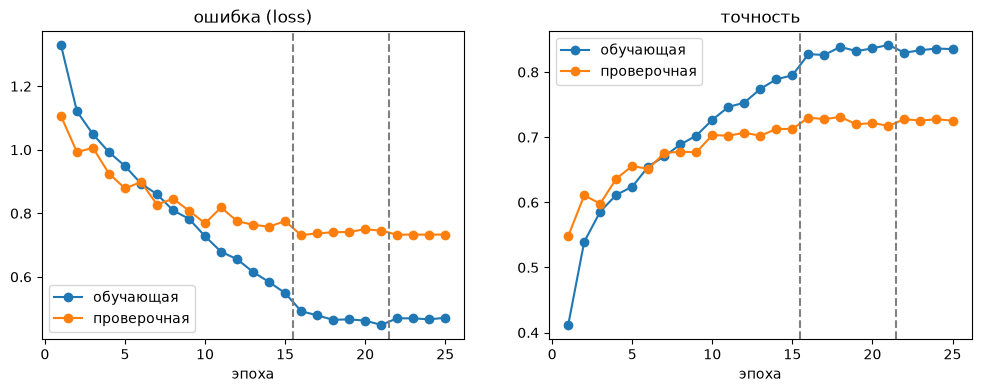

цикл 1 (lr=0.001): эпоха 14 | val_loss 0.7579 | val_acc 0.713
цикл 2 (lr=0.0001): эпоха 16 | val_loss 0.7311 | val_acc 0.730
цикл 3 (lr=1e-05): эпоха 22 | val_loss 0.7325 | val_acc 0.728


In [31]:
# РЕШЕНИЕ ДЗ · шаг 6

plot_history(history)
for c in (1, 2, 3):
    best_of_cycle(c)

*Ваш вывод:* …

---
## Как сдать
1. Ссылка на **этот ноутбук** (доступ «всем, у кого есть ссылка»).
2. Скриншот папки с весами на Google Диске.

Перед сдачей: «Среда выполнения → Перезапустить и выполнить все» — вывод должен быть под каждой ячейкой.